Lasso Regression:

**Y = wX + b**

Y --> Dependent Variable

X --> Independent Variable

w --> weight

b --> bias

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

**Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

Gradient for Weights

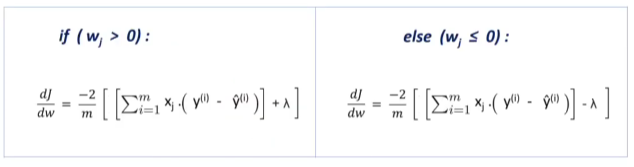

Gradient for Bias

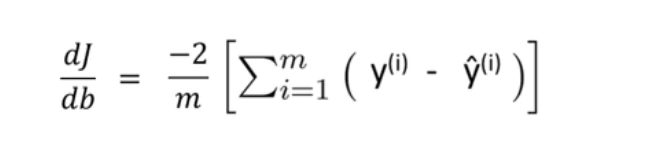

Importing the Dependencies

In [27]:
import numpy  as np

Lasso Regression

In [28]:
# crreating a Class for lasso regression

class Lasso_Regression():

  #initiating The hyperparameters
  def __init__(self, learning_rate, no_of_iterations, lambda_parameter):

    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations
    self.lambda_parameter = lambda_parameter


  # fitting the dataset to the Lasso Regression model
  def fit(self, X, Y):

    #  m -- > number of training examples(data points/no.of rows)
    #  n -- > number of input features (no.of columns)
    self.m, self.n = X.shape

    self.w = np.zeros(self.n)

    self.b = 0

    self.X = X

    self.Y = Y

    # implementing Gradient Descent algorithem for Optimization

    for i in range(self.no_of_iterations):
      self.update_weights()


  # function for updating the weight & bias value
  def update_weights(self, ):

    # linear equation of the model
    Y_prediction = self.predict(self.X)

    # gradient (dw, db)

    # gradients for weight
    dw = np.zeros(self.n)
    for i in range(self.n):

      if self.w[i] > 0:
        dw[i] = (-(2*(self.X[:,i]).dot(self.Y - Y_prediction)) + self.lambda_parameter) / self.m

      else:
        dw[i] = (-(2*(self.X[:,i]).dot(self.Y - Y_prediction)) - self.lambda_parameter) / self.m

    # gradients for bias
    db = -2 * np.sum(self.Y - Y_prediction) / self.m

    self.w = self.w - self.learning_rate * dw
    self.b = self.b - self.learning_rate * db


  # predicting the Target veriable
  def predict(self, X):

    return X.dot(self.w) + self.b

Using Linear Regression model for Prediction



In [29]:
# importing the dependencies
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics

Data Pre-Processing

In [30]:
# loading the data from csv file to a pandas dataframe

salary_data = pd.read_csv('/content/salary_data.csv')

In [31]:
# printing the first 5 columns of the dataframe
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [32]:
# last 5 rows of the dataframe
salary_data.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [33]:
# number of rows & columns in the dataframe
salary_data.shape

(30, 2)

In [34]:
# checking for missing values
salary_data.isnull().sum()

,0
YearsExperience,0
Salary,0


Splitting the feature & target

In [35]:
features = salary_data.iloc[:,:-1].values
target = salary_data.iloc[:,1].values

In [36]:
print(features)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [37]:
print(target)

[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


Splitting the dataset into training & test data

In [38]:
X_train, X_test, Y_train, Y_test = train_test_split(features, target,  test_size=0.2, random_state = 2)

Training the Lasso Regression model





In [39]:
model = Lasso_Regression(learning_rate = 0.02, no_of_iterations=1000, lambda_parameter=200)

In [40]:
model.fit(X_train, Y_train)

Predict the salary value for test data





In [41]:
test_data_prediction = model.predict(X_test)

In [42]:
print(test_data_prediction)

[36828.47602882 34914.40349606 67453.63655312 59797.34642204
 92336.5794791  81809.18054888]


In [43]:
from sklearn import metrics

# R squared error
score_1 = metrics.r2_score(Y_test, test_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_test, test_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.8886504056785421
Mean Absolute Error :  6803.890570382794


Comparing the error with SKLearn Lasso Regression





In [44]:
from sklearn.linear_model import Lasso
sk_model = Lasso()

In [45]:
sk_model.fit(X_train, Y_train)

Lasso()

In [46]:
sk_test_data_prediction = sk_model.predict(X_test)

In [47]:
# R squared error
score_1_ = metrics.r2_score(Y_test, sk_test_data_prediction)

# Mean Absolute Error
score_2_ = metrics.mean_absolute_error(Y_test, sk_test_data_prediction)

print("R squared error : ", score_1_)
print('Mean Absolute Error : ', score_2_)

R squared error :  0.8886986575238741
Mean Absolute Error :  6802.695177040222
